# MAS Lab Notebook - APF-Based Obstacle Avoidance and Formation Control

## 1. Project Overview & Objectives
The goal of this notebook is to design and evaluate a multi-agent system (MAS) capable of navigating an environment while maintaining a structured formation and avoiding static obstacles.

Specifically, we aim to:
1. **Model Agent Dynamics:** Implement a Single Integrator Dynamics system to control the motion of each agent.
2. **Establish Formation Control:** Coordinate a fleet of agents to follow a moving Leader while maintaining a defined target geometry.
3. **Implement Obstacle Avoidance:** Apply Artificial Potential Fields (APF) to prevent collisions between the agents and environmental obstacles.
4. **Enable Dynamic Formation Adaptation:** Introduce a formation-switching mechanism that allows the fleet to alter its shape dynamically to navigate narrow passages.

---

## 2. Methodology & Incremental Development Strategy
Given the complexity of multi-agent control systems, we adopt an **incremental, step-by-step approach**. Each component is developed, tested, and validated independently prior to system integration:

* **Step 1:** Single Integrator Dynamics & Target Following (`SimpleAgent`)
* **Step 2:** APF Interfaces & Obstacle Representation (`PotentialField`, `Obstacle`)
* **Step 3:** Strategy-Based Behaviors & Refactored Agent (`Agent`, `VelocityBehavior`)
* **Step 4:** Distance-Based Formation Control (`MutualDistanceKeeping`)
* **Step 5:** Dynamic Formation Adaptation & Full Pipeline Integration (`FormationManager`)

---
## 3. Experimentation
### 3.1 Requirements
We use a Python environment with the following core dependencies:
  - `python>=3.10`
  - `ipykernel`
  - `matplotlib`
  - `numpy`
  - `shapely`


In [1]:
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Callable, Protocol
from abc import ABC, abstractmethod
import itertools
import numpy as np
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 50.0
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter, ArtistAnimation
from IPython.display import HTML, Image, display
from PIL import Image as PILImage, ImageSequence
from shapely.geometry import Point, Polygon, LineString, base
from shapely.ops import nearest_points


### 3.2 The `SimpleAgent` Class (Single Integrator Dynamics)
A `SimpleAgent` represents a single-integrator point mass moving in 2D space toward a given target with a constant nominal speed.


In [2]:
def normalize(v: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(v)
    if norm == 0.0:
        return np.zeros_like(v)
    return v / norm


@dataclass
class SimpleAgent:
    position: np.ndarray
    target: np.ndarray
    speed: float

    def __post_init__(self):
        self.position = np.array(self.position, dtype=float)
        self.target = np.array(self.target, dtype=float)

    def direction_to_target(self) -> np.ndarray:
        return normalize(self.target - self.position)

    def velocity(self) -> np.ndarray:
        return self.speed * self.direction_to_target()

    def step(self, dt: float) -> None:
        if self.reached_target(tol=self.speed * dt):
            self.position = self.target.copy()
            return
        self.position = self.position + dt * self.velocity()

    def distance_to_target(self) -> float:
        return np.linalg.norm(self.target - self.position)

    def reached_target(self, tol: float = 1e-2) -> bool:
        return self.distance_to_target() <= tol


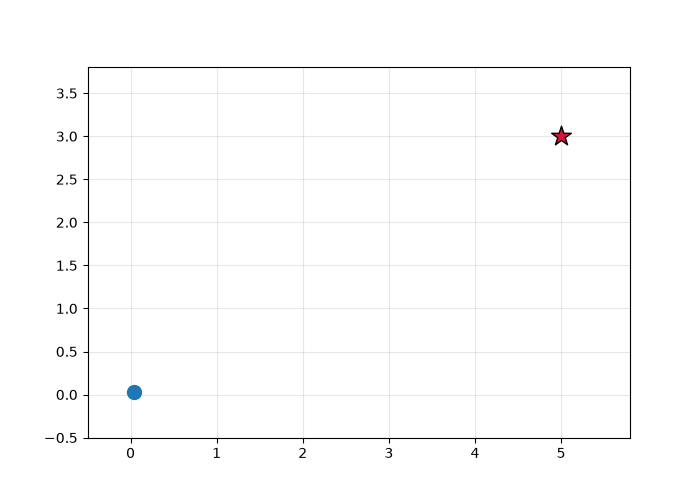

In [3]:
agent = SimpleAgent(position=[0.0, 0.0], target=[5.0, 3.0], speed=1.0)

def make_animation():
    dt = 0.05
    frames = 125

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_xlim(-0.5, 5.8)
    ax.set_ylim(-0.5, 3.8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title('Single-integrator target following')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    ax.scatter(
        [agent.target[0]], [agent.target[1]],
        marker="*", s=220, color="crimson",
        edgecolors="black", zorder=4, label="target"
    )
    path_line, = ax.plot([], [], '--', color='tab:blue', lw=2.0, label='trajectory')
    agent_point, = ax.plot([], [], 'o', color='tab:blue', markersize=10, label='agent')
    time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, va='top')
    dist_text = ax.text(0.02, 0.92, '', transform=ax.transAxes, va='top')
    ax.legend(loc='lower right')

    xs = [agent.position[0]]
    ys = [agent.position[1]]

    def init():
        path_line.set_data(xs, ys)
        agent_point.set_data([agent.position[0]], [agent.position[1]])
        time_text.set_text('t = 0.00 s')
        dist_text.set_text(f'distance = {agent.distance_to_target():.2f}')
        return path_line, agent_point, time_text, dist_text

    def update(frame):
        agent.step(dt)
        xs.append(agent.position[0])
        ys.append(agent.position[1])
        path_line.set_data(xs, ys)
        agent_point.set_data([agent.position[0]], [agent.position[1]])
        time_text.set_text(f't = {(frame + 1) * dt:.2f} s')
        dist_text.set_text(f'distance = {agent.distance_to_target():.2f}')
        return path_line, agent_point, time_text, dist_text

    anim = FuncAnimation(
        fig,
        update,
        init_func=init,
        frames=frames,
        interval=50,
        blit=True
    )
    anim.save("assets/simple_agent.gif", writer=PillowWriter(fps=20))
    plt.close(fig)
    display(Image(filename="assets/simple_agent.gif"))


if __name__ == '__main__':
    make_animation()

### 3.3 The `PotentialField` Interface
Most entities in our environment represent physical objects. To avoid collisions, we define a lightweight `PotentialField` interface exposing repulsive force computation and distance queries.


In [4]:
from typing import Protocol
from shapely.geometry import Point, Polygon, LineString, base
from shapely.ops import nearest_points


class PotentialField(Protocol):
    """Interface implemented by any obstacle or agent generating potential field forces."""

    def repulsive_potential(self, position: np.ndarray, beta: float = 2.0) -> float:
        """Scalar repulsive potential J_rep(q) at `position`."""
        ...

    def repulsive_force(self, position: np.ndarray, gain: float = 1.0, beta: float = 2.0) -> np.ndarray:
        """Negative gradient force vector -grad J_rep(q) acting on `position`."""
        ...

    def distance_to(self, position: np.ndarray) -> float:
        """Shortest distance from `position` to this potential field source."""
        ...

### 3.4 The `Obstacle` Class
This class wraps an arbitrary `Shapely` geometry using composition. The underlying geometry is maintained as an attribute while domain-specific methods (such as APF repulsive potential and force computation) are exposed.

#### Repulsive Potential & Negative Gradient Formulation
When an agent enters the influence radius $\delta_0$ of obstacle $k$, the **repulsive potential** is defined as:
$$J_{\text{rep},k}(\mathbf{q}) = \begin{cases} \frac{1}{\beta} \left( \frac{1}{d(\mathbf{q}, \mathcal{O}_k) - \delta} - \frac{1}{\delta_0 - \delta} \right)^\beta & \text{if } d(\mathbf{q}, \mathcal{O}_k) < \delta_0 \\ 0 & \text{if } d(\mathbf{q}, \mathcal{O}_k) \ge \delta_0 \end{cases}$$

Under single-integrator dynamics, the control policy steers the robot along the **negative gradient** (steepest descent) of the potential:
$$\mathbf{F}_{\text{rep},k}(\mathbf{q}) = -\nabla J_{\text{rep},k}(\mathbf{q}) = \frac{1}{(d(\mathbf{q}, \mathcal{O}_k) - \delta)^2} \left( \frac{1}{d(\mathbf{q}, \mathcal{O}_k) - \delta} - \frac{1}{\delta_0 - \delta} \right)^{\beta - 1} \nabla d(\mathbf{q})$$

where:
- $\beta$ is the exponent parameter (typically $\beta = 2$, which simplifies the outer factor $\frac{1}{\beta} \cdot \beta = 1$),
- $d(\mathbf{q}, \mathcal{O}_k)$ is the Euclidean distance from agent position $\mathbf{q}$ to obstacle $\mathcal{O}_k$,
- $\delta$ is the safe distance at which the barrier potential asymptotically diverges,
- $\delta_0$ is the influence radius of the obstacle,
- $\nabla d(\mathbf{q}) = \frac{\mathbf{q} - \mathbf{c}^*}{\|\mathbf{q} - \mathbf{c}^*\|}$ is the unit outward normal vector from the closest point $\mathbf{c}^*$ on the obstacle boundary.

In [5]:
@dataclass
class Obstacle:
    geometry: base.BaseGeometry
    name: str = "obstacle"
    influence_radius: float = 1.5
    safe_distance: float = 1.0

    def distance_to(self, position: np.ndarray) -> float:
        p = Point(position)
        return p.distance(self.geometry)

    def closest_point(self, position: np.ndarray) -> np.ndarray:
        p = Point(position)
        _, nearest_on_obstacle = nearest_points(p, self.geometry)
        return np.array([nearest_on_obstacle.x, nearest_on_obstacle.y])

    def repulsive_potential(self, position: np.ndarray, beta: float = 2.0) -> float:
        """Scalar repulsive potential J_rep(q)."""
        d = self.distance_to(position)
        if d >= self.influence_radius:
            return 0.0
        d_eff = max(d, self.safe_distance + 1e-6)
        return (1.0 / beta) * (
            (1.0 / (d_eff - self.safe_distance)) - (1.0 / (self.influence_radius - self.safe_distance))
        ) ** beta

    def repulsive_force(self, position: np.ndarray, gain: float = 1.0, beta: float = 2.0) -> np.ndarray:
        """
        Negative gradient force: F_rep = -grad J_rep(q).
        F = gain * (1 / (d - delta)^2) * (1/(d - delta) - 1/(delta_0 - delta))^(beta - 1) * n_hat
        """
        if not (0 <= self.safe_distance < self.influence_radius):
            self.safe_distance = max(0.0, min(self.safe_distance, self.influence_radius - 0.5))

        d = self.distance_to(position)
        if d >= self.influence_radius or d <= 1e-9:
            return np.zeros(2)

        closest = self.closest_point(position)
        direction = position - closest
        norm = np.linalg.norm(direction)
        if norm < 1e-9:
            return np.zeros(2)
        direction = direction / norm

        d_eff = max(d, self.safe_distance + 1e-6)
        magnitude = gain * (1.0 / (d_eff - self.safe_distance) ** 2) * (
            (1.0 / (d_eff - self.safe_distance)) - (1.0 / (self.influence_radius - self.safe_distance))
        ) ** (beta - 1.0)
        magnitude = min(magnitude, MAX_REPULSIVE_FORCE)
        return magnitude * direction

    def plot(self, ax, color="gray", alpha=0.5, **kwargs):
        """Draw the underlying shapely geometry on a matplotlib Axes."""
        geom = self.geometry
        if geom.geom_type == "Polygon":
            xs, ys = geom.exterior.xy
            ax.fill(xs, ys, color=color, alpha=alpha, **kwargs)
        elif geom.geom_type == "Point":
            ax.plot(geom.x, geom.y, "o", color=color, markersize=12, **kwargs)
        elif geom.geom_type in ("LineString", "LinearRing"):
            xs, ys = geom.xy
            ax.plot(xs, ys, color=color, linewidth=3, **kwargs)
        else:
            raise NotImplementedError(f"Plotting not implemented for {geom.geom_type}")
        return ax


def make_circular_obstacle(center: Tuple[float, float], radius: float, name="circle", influence_radius: float = 1.5) -> Obstacle:
    """Convenience factory: circle approximated by a buffered Point."""
    geom = Point(center).buffer(radius, resolution=32)
    return Obstacle(geometry=geom, name=name, influence_radius=influence_radius)


def make_rectangular_obstacle(x_min, y_min, x_max, y_max, name="rect", influence_radius: float = 1.5) -> Obstacle:
    geom = Polygon([(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)])
    return Obstacle(geometry=geom, name=name, influence_radius=influence_radius)

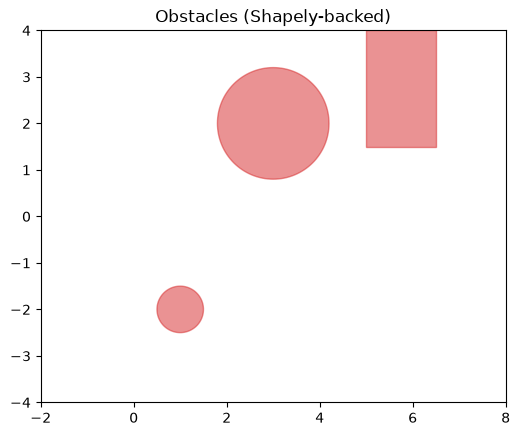

In [6]:
obstacles: List[Obstacle] = [
    make_circular_obstacle((3.0, 2.0), 1.2, name="circ1"),
    make_rectangular_obstacle(5, 1.5, 6.5, 4.0, name="rect1"),
    make_circular_obstacle((1.0, -2.0), 0.5, name="circ2"),
]

fig, ax = plt.subplots(figsize=(6, 6))
for obs in obstacles:
    obs.plot(ax, color="tab:red")

ax.set_xlim(-2, 8)
ax.set_ylim(-4, 4)
ax.set_aspect("equal")
ax.set_title("Obstacles (Shapely-backed)")
plt.show()


### 3.5 Strategy Pattern for `Agent` Behaviors

To combine modular behaviors (e.g., *target seeking*, *obstacle avoidance*, and *formation distance keeping*), we implement the **Strategy Pattern**.

The abstract base class `VelocityBehavior` defines the common interface for motion strategies. Each concrete strategy implements `compute_velocity(agent)`:
- `GoalSeeking`: computes an attractive velocity vector directed toward the agent's target.
- `ObstacleAvoidanceAPF`: aggregates repulsive force vectors from nearby `PotentialField` sources.
- `MutualDistanceKeeping`: applies inter-agent distance constraints to maintain geometric formations.


In [7]:
from abc import ABC, abstractmethod
from typing import Callable


class VelocityBehavior(ABC):
    """Strategy interface: each behavior contributes a velocity vector component."""

    @abstractmethod
    def compute_velocity(self, agent: "Agent") -> np.ndarray:
        """Compute velocity contribution based on agent state and environment."""
        pass


@dataclass
class ObstacleAvoidanceAPF(VelocityBehavior):
    obstacles: Callable[[], List[PotentialField]] = field(default_factory=list)
    gain: float = 1.0
    beta: float = 2.0

    def compute_velocity(self, agent: "Agent") -> np.ndarray:
        total = np.zeros(2)
        for f in self.obstacles():
            total += f.repulsive_force(agent.position, self.gain, self.beta)
        return total


@dataclass
class GoalSeeking(VelocityBehavior):
    k: float = 1.0

    def compute_velocity(self, agent: "Agent") -> np.ndarray:
        if agent.target is None:
            return np.zeros(2)
        return self.k * (agent.target - agent.position)

#### 3.5.1 The `Agent` Class
We now define the full `Agent` class, which evaluates its assigned `behaviors` and executes motion updates.

**Key Design Principles:**
- **Proportional Velocity Saturation:** Instead of forcing a constant non-zero speed via direction normalization, the combined velocity vector is clipped to `self.speed` ($v_{\max}$). When the net force is small (e.g., near the target or at formation equilibrium), the agent smoothly decelerates to rest.
- **Safe Optional Target:** Followers in a formation may not possess an independent goal target. `target` is safely typed as `Optional[np.ndarray] = None`, avoiding `NaN` propagation.
- **PotentialField Compatibility:** Each `Agent` also acts as a dynamic `PotentialField`, enabling inter-agent collision avoidance.


In [8]:
MAX_REPULSIVE_FORCE = 50.0  # Maximum repulsive force magnitude to avoid numerical instability


@dataclass
class Agent:
    position: np.ndarray
    behaviors: List[VelocityBehavior] = field(default_factory=list)
    target: Optional[np.ndarray] = None
    speed: float = 1.0  # Maximum velocity magnitude (v_max)
    influence_radius: float = 0.6
    safe_distance: float = 0.3
    
    def __post_init__(self):
        self.position = np.array(self.position, dtype=float)
        if self.target is not None:
            self.target = np.array(self.target, dtype=float)
            self.heading = self.direction_to_target()
        else:
            self.target = None
            self.heading = np.array([1.0, 0.0])

    def distance_to(self, position: np.ndarray) -> float:
        return np.linalg.norm(self.position - position)

    def closest_point(self, position: np.ndarray) -> np.ndarray:
        return self.position.copy()

    def direction_to_target(self) -> np.ndarray:
        if self.target is None:
            return np.zeros(2)
        return normalize(self.target - self.position)

    def velocity(self) -> np.ndarray:
        v = np.zeros_like(self.position)
        for behavior in self.behaviors:
            v += behavior.compute_velocity(self)
        norm_v = np.linalg.norm(v)
        if norm_v > self.speed:
            return (v / norm_v) * self.speed
        return v

    def step(self, dt: float) -> None:
        if self.target is not None and self.reached_target(tol=self.speed * dt):
            self.position = self.target.copy()
            return
        v = self.velocity()
        if np.linalg.norm(v) > 1e-9:
            self.heading = normalize(v)
        self.position += v * dt

    def distance_to_target(self) -> float:
        if self.target is None:
            return float('inf')
        return np.linalg.norm(self.target - self.position)

    def reached_target(self, tol: float = 1e-2) -> bool:
        if self.target is None:
            return False
        return self.distance_to_target() <= tol

    def repulsive_potential(self, position: np.ndarray, beta: float = 2.0) -> float:
        """Scalar repulsive potential J_rep(q)."""
        d = self.distance_to(position)
        if d >= self.influence_radius:
            return 0.0
        d_eff = max(d, self.safe_distance + 1e-6)
        return (1.0 / beta) * (
            (1.0 / (d_eff - self.safe_distance)) - (1.0 / (self.influence_radius - self.safe_distance))
        ) ** beta

    def repulsive_force(self, position: np.ndarray, gain: float = 1.0, beta: float = 2.0) -> np.ndarray:
        """Negative gradient force -grad J_rep(q) acting on position."""
        if not (0 <= self.safe_distance < self.influence_radius):
            self.safe_distance = max(0.0, min(self.safe_distance, self.influence_radius - 0.5))

        d = self.distance_to(position)
        if d >= self.influence_radius or d <= 1e-9:
            return np.zeros(2)

        closest = self.closest_point(position)
        direction = position - closest
        norm = np.linalg.norm(direction)
        if norm < 1e-9:
            return np.zeros(2)
        direction = direction / norm

        d_eff = max(d, self.safe_distance + 1e-6)
        magnitude = gain * (1.0 / (d_eff - self.safe_distance) ** 2) * (
            (1.0 / (d_eff - self.safe_distance)) - (1.0 / (self.influence_radius - self.safe_distance))
        ) ** (beta - 1.0)
        magnitude = min(magnitude, MAX_REPULSIVE_FORCE)
        return magnitude * direction

#### 3.5.2 Multi-Agent APF Obstacle and Collision Avoidance
We test two agents moving toward opposing targets while avoiding static obstacles and avoiding each other through inter-agent APF repulsion.


In [9]:
def show_gif_player(gif_path: str, fps: int = 30, stride: int = 1, interactive: bool = False):
    """
    Display animation from disk.
    
    Parameters
    ----------
    gif_path : str
        Path to the saved GIF file.
    fps : int, optional
        Playback speed (frames per second) for the interactive player.
    stride : int, optional
        Subsampling factor for the interactive player frames.
    interactive : bool, optional
        If False (default), displays the standard GIF image directly. This renders natively
        and cleanly on GitHub's notebook viewer without relying on JavaScript.
        If True, renders an interactive HTML player console (Play/Pause/Scrubber)
        for local Jupyter sessions.
    """
    if not interactive:
        display(Image(filename=gif_path))
        return

    im = PILImage.open(gif_path)
    frames = [frame.convert("RGB") for frame in ImageSequence.Iterator(im)][::stride]
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=80)
    ax.axis("off")
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    artists = [[ax.imshow(f, animated=True)] for f in frames]
    anim = ArtistAnimation(fig, artists, interval=(1000 / fps) * stride, blit=True)
    plt.close(fig)
    display(HTML(anim.to_jshtml()))

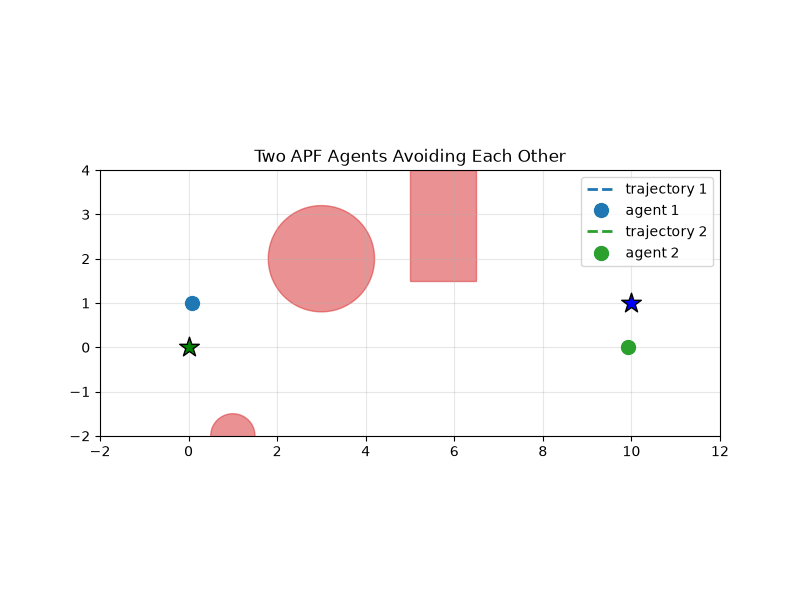

In [10]:
agent1 = Agent(
    position=[0, 1],
    behaviors=[
        GoalSeeking(k=1.0)
    ],
    target=[10, 1],
    speed=1.0
)
agent2 = Agent(
    position=[10, 0],
    behaviors=[
        GoalSeeking(k=1.0)
    ],
    target=[0, 0],
    speed=1.0
)

agents = [agent1, agent2]  # define this once, after both agents exist

agent1.behaviors.insert(0, ObstacleAvoidanceAPF(
    obstacles=lambda: obstacles + [a for a in agents if a is not agent1],
    gain=2.0
))
agent2.behaviors.insert(0, ObstacleAvoidanceAPF(
    obstacles=lambda: obstacles + [a for a in agents if a is not agent2],
    gain=2.0
))

dt = 0.04
n_frame = 300
steps_per_frame = 2  # Subsampling to speed up animation

fig, ax = plt.subplots(figsize=(8, 6))
for obs in obstacles:
    obs.plot(ax, color="tab:red", alpha=0.5)

# Initialize path lines and agent points
pathline1, = ax.plot([], [], "--", color="tab:blue", lw=2.0, label="trajectory 1")
agentpoint1, = ax.plot([], [], "o", color="tab:blue", markersize=10, label="agent 1")

pathline2, = ax.plot([], [], "--", color="tab:green", lw=2.0, label="trajectory 2")
agentpoint2, = ax.plot([], [], "o", color="tab:green", markersize=10, label="agent 2")

ax.set_xlim(-2, 12)
ax.set_ylim(-2, 4)
ax.set_aspect("equal")
ax.set_title("Two APF Agents Avoiding Each Other")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

xs1, ys1 = [agent1.position[0]], [agent1.position[1]]
xs2, ys2 = [agent2.position[0]], [agent2.position[1]]
ax.scatter(
    [agent1.target[0]], [agent1.target[1]],
    marker="*", s=220, color="blue",
    edgecolors="black", zorder=4, label="target 1"
)
ax.scatter(
    [agent2.target[0]], [agent2.target[1]],
    marker="*", s=220, color="green",
    edgecolors="black", zorder=4, label="target 2"
)

def init():
    pathline1.set_data(xs1, ys1)
    agentpoint1.set_data([agent1.position[0]], [agent1.position[1]])
    pathline2.set_data(xs2, ys2)
    agentpoint2.set_data([agent2.position[0]], [agent2.position[1]])
    return pathline1, agentpoint1, pathline2, agentpoint2

def update(frame):
    for _ in range(steps_per_frame):
        agent1.step(dt)
        agent2.step(dt)
        xs1.append(agent1.position[0])
        ys1.append(agent1.position[1])
        xs2.append(agent2.position[0])
        ys2.append(agent2.position[1])
    pathline1.set_data(xs1, ys1)
    agentpoint1.set_data([agent1.position[0]], [agent1.position[1]])
    pathline2.set_data(xs2, ys2)
    agentpoint2.set_data([agent2.position[0]], [agent2.position[1]])
    return pathline1, agentpoint1, pathline2, agentpoint2

anim = FuncAnimation(fig, update, init_func=init, frames=n_frame // steps_per_frame, interval=30, blit=True)
anim.save("assets/two_agents_apf.gif", writer=PillowWriter(fps=25))
plt.close(fig)
show_gif_player("assets/two_agents_apf.gif", fps=25)

#### 3.5.3 Formation Control (Leader-Follower Framework)
Formation control is achieved by defining inter-agent distance constraints. A `DistanceConstraint` computes a non-linear spring restoring force proportional to the difference between current and desired squared Euclidean distances:
$$\mathbf{F}_{ij} = -k \left( \|\mathbf{p}_i - \mathbf{p}_j\|^2 - d_{ij}^2 \right) (\mathbf{p}_i - \mathbf{p}_j)$$

**Key Control Insights:**
1. **Constraint Stiffness ($k$):** Under single-integrator dynamics, a follower tracking a leader moving at steady velocity $v_L$ experiences a steady-state displacement error $e_{ss} \approx \frac{v_L}{2 k d_{ij}}$. A soft spring ($k=1.0$) causes noticeable elastic stretching (+32.5% elongation). Increasing the gain to $k=10.0$ tightens the constraint, reducing tracking lag to under 1% error.
2. **Follower Velocity Margin (Control Authority):** For followers to rapidly catch up from perturbed initial conditions or recover geometry after dodging obstacles, their maximum velocity capability must exceed the leader's cruise speed ($v_{\max, \text{follower}} \approx 1.8 > v_L = 1.0$). Once in formation, the proportional velocity law ensures followers travel smoothly at $v_L$.
3. **Hierarchical Directed Constraints (DAG):** In undirected constraint graphs, symmetric restoring forces cause rearward followers to pull forward agents backward during formation transitions. By structuring the topology as a **Directed Acyclic Graph (DAG)** (`parent -> child`), force is exerted exclusively on the downstream follower (`child`), preventing forward agents from being dragged backward during reformation.


In [11]:
@dataclass
class DistanceConstraint:
    parent: Agent  # Upstream reference agent in the hierarchy
    child: Agent   # Downstream follower agent in the hierarchy
    desired_distance: float
    k: float = 10.0  # Spring stiffness gain
    directed: bool = True  # If True, force acts only on child, never pulling parent backward
    
    def force_on_parent(self) -> np.ndarray:
        diff = self.parent.position - self.child.position
        sq_error = np.dot(diff, diff) - self.desired_distance ** 2
        return -sq_error * diff

    def force_on(self, agent: Agent) -> np.ndarray:
        if agent is self.child:
            return -self.k * self.force_on_parent()
        elif agent is self.parent:
            if self.directed:
                return np.zeros_like(agent.position)
            return self.k * self.force_on_parent()
        raise ValueError("Agent not part of this constraint.")


@dataclass
class MutualDistanceKeeping(VelocityBehavior):
    constraints: List[DistanceConstraint] = field(default_factory=list)
    
    def compute_velocity(self, agent: Agent) -> np.ndarray:
        total = np.zeros_like(agent.position)
        for c in self.constraints:
            total += c.force_on(agent)
        return total


In [12]:
agent1 = Agent(position=[-0.5, 0], behaviors=[GoalSeeking(k=1.0)], target=[10, 1], speed=1.0)
agent2 = Agent(position=[-1, 0.2], speed=1.8)
agent3 = Agent(position=[-1, -0.2], speed=1.8)
agent4 = Agent(position=[-1.3, 0.5], speed=1.8)
agent5 = Agent(position=[-1.3, 0.0], speed=1.8)
agent6 = Agent(position=[-1.3, -0.5], speed=1.8)

c_12 = DistanceConstraint(parent=agent1, child=agent2, desired_distance=1.0, k=10.0)
c_13 = DistanceConstraint(parent=agent1, child=agent3, desired_distance=1.0, k=10.0)
c_15 = DistanceConstraint(parent=agent1, child=agent5, desired_distance=np.sqrt(3), k=10.0)
c_23 = DistanceConstraint(parent=agent2, child=agent3, desired_distance=1.0, k=10.0)
c_25 = DistanceConstraint(parent=agent2, child=agent5, desired_distance=1.0, k=10.0)
c_35 = DistanceConstraint(parent=agent3, child=agent5, desired_distance=1.0, k=10.0)
c_24 = DistanceConstraint(parent=agent2, child=agent4, desired_distance=1.0, k=10.0)
c_34 = DistanceConstraint(parent=agent3, child=agent4, desired_distance=np.sqrt(3), k=10.0)
c_54 = DistanceConstraint(parent=agent5, child=agent4, desired_distance=1.0, k=10.0)
c_26 = DistanceConstraint(parent=agent2, child=agent6, desired_distance=np.sqrt(3), k=10.0)
c_36 = DistanceConstraint(parent=agent3, child=agent6, desired_distance=1.0, k=10.0)
c_56 = DistanceConstraint(parent=agent5, child=agent6, desired_distance=1.0, k=10.0)

agents = [agent1, agent2, agent3, agent4, agent5, agent6]

agent1.behaviors.append(MutualDistanceKeeping([]))
agent2.behaviors.append(MutualDistanceKeeping([c_12]))
agent3.behaviors.append(MutualDistanceKeeping([c_13, c_23]))
agent4.behaviors.append(MutualDistanceKeeping([c_24, c_34, c_54]))
agent5.behaviors.append(MutualDistanceKeeping([c_15, c_25, c_35]))
agent6.behaviors.append(MutualDistanceKeeping([c_26, c_36, c_56]))


In [13]:
dt = 0.02
n_frame = 700
steps_per_frame = 3  # Subsampling to speed up animation

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

fig, ax = plt.subplots(figsize=(8, 6))

# Initialize path lines and agent points
pathlines = []
agentpoints = []
for i, agent in enumerate(agents):
    pathline, = ax.plot([], [], "--", lw=2.0, color=colors[i], label=f"trajectory {i+1}")
    agentpoint, = ax.plot([], [], "o", markersize=10, color=colors[i], label=f"agent {i+1}")
    pathlines.append(pathline)
    agentpoints.append(agentpoint)

ax.set_xlim(-2, 16)
ax.set_ylim(-2, 6)
ax.set_aspect("equal")
ax.set_title("Multi-Agent Formation Control (Triangle Formation)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

xss, yss = [[agent.position[0]] for agent in agents], [[agent.position[1]] for agent in agents] 
ax.scatter(
    [agent1.target[0]], [agent1.target[1]],
    marker="*", s=220, color="blue",
    edgecolors="black", zorder=4, label="target 1"
)

def init():
    for i, agent in enumerate(agents):
        pathlines[i].set_data([agent.position[0]], [agent.position[1]])
        agentpoints[i].set_data([agent.position[0]], [agent.position[1]])
    return *pathlines, *agentpoints

def update(frame):
    for _ in range(steps_per_frame):
        for i, agent in enumerate(agents):
            agent.step(dt)
            xss[i].append(agent.position[0])
            yss[i].append(agent.position[1])
    for i, agent in enumerate(agents):
        pathlines[i].set_data(xss[i], yss[i])
        agentpoints[i].set_data([agent.position[0]], [agent.position[1]])
    return *pathlines, *agentpoints

# print distance between agent1 and every other agent at start
for i, agent in enumerate(agents[1:], start=2):
    print(f"Distance between agent1 and agent{i} at start: {np.linalg.norm(agent1.position - agent.position):.2f}")

anim = FuncAnimation(fig, update, init_func=init, frames=n_frame // steps_per_frame, interval=30, blit=True)
anim.save("assets/triangle_formation.gif", writer=PillowWriter(fps=30))
plt.close(fig)
show_gif_player("assets/triangle_formation.gif", fps=30)

# print distance between agent1 and every other agent at last frame
for i, agent in enumerate(agents[1:], start=2):
    print(f"Distance between agent1 and agent{i} at last frame: {np.linalg.norm(agent1.position - agent.position):.2f}")

#### 3.5.4 Dynamic Formation Adaptation
**Core concept**: The leader agent continuously inspects the forward environment using a virtual `Probe`. If an upcoming passage is narrower than the lateral footprint of the fleet formation, a transition to a single-file line formation is triggered.

**Line Formation Geometry:**
To achieve a robust single-file formation, constraints are defined such that:
- Each follower $i$ maintains a distance of $1$ unit from predecessor $i-1$.
- Each follower $i$ maintains a distance of $i \times \text{unit}$ from the leader (agent $0$).

By the triangle inequality ($d(0, i) \le d(0, i-1) + d(i-1, i)$), setting $d(0, i) = d(0, i-1) + d(i-1, i)$ forces the triangle formed by $(0, i-1, i)$ to collapse collinearly into a straight line segment.

The `detect_narrow_gap` function constructs a forward corridor along the probe's heading of length `lookahead` and width `formation_width + margin`. If two or more obstacles intersect this corridor, it verifies whether the clearance between any pair is less than the required footprint.


In [14]:
import itertools
from shapely.geometry import LineString


@dataclass
class Probe:
    position: np.ndarray
    heading: np.ndarray


def detect_narrow_gap(probe, obstacles: List[Obstacle], lookahead: float = 3.0, formation_width: float = 1.0, margin: float = 0.3):
    """
    Searches along the heading of `probe` for two obstacles whose gap is narrower than the current lateral footprint of the formation. Returns the width of the gap if a narrow passage is detected ahead, otherwise None.
    """
    heading = normalize(probe.heading)
    if np.linalg.norm(heading) == 0.0:
        return None

    # Create a corridor along the probe's heading, extending `lookahead` distance ahead, and with a width of `formation_width + margin`.
    corridor = LineString([
        probe.position,
        probe.position + heading * lookahead,
    ]).buffer((formation_width + margin) / 2 , cap_style="flat")

    nearby = [o for o in obstacles if o.geometry.intersects(corridor)]
    if len(nearby) < 2:
        return None

    min_gap = min(
        a.geometry.distance(b.geometry)
        for a, b in itertools.combinations(nearby, 2)
    )
    if min_gap < formation_width + margin:
        return min_gap
    return None


To decide when the fleet has cleared the bottleneck and can safely return to the original wide formation, we apply the **Strategy Pattern** via the `ReformationCriterion` interface (`should_reform`):

- `CentroidGapCriterion`: places the `Probe` at the fleet centroid and checks if the forward gap is clear.
- `LastAgentGapCriterion`: places the `Probe` at the position of the rearmost agent in the line.
- `TraveledDistanceCriterion`: records the leader's trigger position upon entering narrow mode, signaling reformation once the leader has advanced by $(N - 1 + \text{lookahead}) \times \text{unit}$.


In [15]:
class ReformationCriterion(ABC):
    """Strategy interface: determines when the fleet should revert to the original formation."""

    @abstractmethod
    def should_reform(self, manager: "FormationManager") -> bool:
        pass

    def on_narrow_detected(self, manager: "FormationManager") -> None:
        """Hook called once when the fleet switches into narrow formation."""
        pass


@dataclass
class CentroidGapCriterion(ReformationCriterion):
    lookahead: float = 3.0
    margin: float = 0.3

    def should_reform(self, manager: "FormationManager") -> bool:
        positions = np.array([a.position for a in manager.agents])
        centroid = positions.mean(axis=0)
        probe = Probe(position=centroid, heading=manager.agents[0].heading)
        gap = detect_narrow_gap(
            probe, manager.obstacles,
            lookahead=self.lookahead,
            formation_width=manager.formation_width,
            margin=self.margin,
        )
        return gap is None


@dataclass
class LastAgentGapCriterion(ReformationCriterion):
    lookahead: float = 3.0
    margin: float = 0.3

    def should_reform(self, manager: "FormationManager") -> bool:
        last = manager.agents[-1]
        probe = Probe(position=last.position, heading=manager.agents[0].heading)
        gap = detect_narrow_gap(
            probe, manager.obstacles,
            lookahead=self.lookahead,
            formation_width=manager.formation_width,
            margin=self.margin,
        )
        return gap is None


@dataclass
class TraveledDistanceCriterion(ReformationCriterion):
    trigger_position: Optional[np.ndarray] = field(default=None, repr=False)

    def on_narrow_detected(self, manager: "FormationManager") -> None:
        self.trigger_position = manager.agents[0].position.copy()

    def should_reform(self, manager: "FormationManager") -> bool:
        if self.trigger_position is None:
            return False
        traveled = np.linalg.norm(manager.agents[0].position - self.trigger_position)
        threshold = (len(manager.agents) - 1 + manager.lookahead) * manager.unit
        return traveled >= threshold


`TRIANGLE_SPECS` defines the constraint graph for the wide formation as a list of `(i, j, desired_distance)` tuples, where index `0` represents the leader.

`build_line_formation_specs(n_agents, unit)` generates the constraint topology for the single-file line formation.


In [16]:
# Hierarchical DAG specifications: (parent_index, child_index, desired_distance)
TRIANGLE_SPECS = [
    (0, 1, 1.0),          # Leader -> Agent 2
    (0, 2, 1.0),          # Leader -> Agent 3
    (0, 4, np.sqrt(3)),   # Leader -> Agent 5
    (1, 2, 1.0),          # Agent 2 -> Agent 3
    (1, 4, 1.0),          # Agent 2 -> Agent 5
    (2, 4, 1.0),          # Agent 3 -> Agent 5
    (1, 3, 1.0),          # Agent 2 -> Agent 4
    (2, 3, np.sqrt(3)),   # Agent 3 -> Agent 4
    (4, 3, 1.0),          # Agent 5 -> Agent 4
    (1, 5, np.sqrt(3)),   # Agent 2 -> Agent 6
    (2, 5, 1.0),          # Agent 3 -> Agent 6
    (4, 5, 1.0),          # Agent 5 -> Agent 6
]


def build_line_formation_specs(n_agents: int, unit: float = 1.0) -> List[Tuple[int, int, float]]:
    """
    Build hierarchical single-file formation specifications.
    Index 0 is the leader. Each follower i is constrained to its parent predecessor i-1
    (distance = unit) and directly to the leader 0 (distance = i * unit).
    """
    specs = []
    for i in range(1, n_agents):
        specs.append((i - 1, i, unit))
        if i > 1:
            specs.append((0, i, i * unit))
    return specs


#### 3.5.5 The `FormationManager` Class

The `FormationManager` coordinates fleet-wide formation topology transitions.

**Core Responsibilities:**
- **State & Timing:** Tracks active topology (`current`), transition timing, and enforces `min_dwell_time` to prevent state chattering.
- **Dynamic Rewiring:** Reconfigures each agent's `MutualDistanceKeeping` constraints when transitioning between formations.
- **Probing & Triggering:** Coordinates forward sensing and invokes the selected `ReformationCriterion`.


In [17]:
@dataclass
class FormationManager:
    agents: List[Agent]
    obstacles: List[Obstacle]
    reformation_criterion: ReformationCriterion
    unit: float = 1.0
    lookahead: float = 3.0
    margin: float = 0.3
    min_dwell_time: float = 2.0
    formation_width: float = 1.3  # Nominal lateral footprint of wide formation
    constraint_k: float = 10.0  # Formation spring stiffness gain
    directed: bool = True  # Enable Directed Acyclic Graph (DAG) constraints
    current: str = "triangle"
    _time_in_state: float = field(default=0.0, repr=False)

    def __post_init__(self):
        self._line_specs = build_line_formation_specs(len(self.agents), self.unit)
        self._triangle_specs = TRIANGLE_SPECS
        self._apply_specs(self._triangle_specs)  # Activate initial formation

    def _mdk(self, agent: Agent) -> MutualDistanceKeeping:
        return next(b for b in agent.behaviors if isinstance(b, MutualDistanceKeeping))

    def lateral_extent(self) -> float:
        """Instantaneous lateral footprint measured perpendicular to leader heading."""
        heading = normalize(self.agents[0].heading)
        perp = np.array([-heading[1], heading[0]])
        projections = np.array([a.position for a in self.agents]) @ perp
        return float(projections.max() - projections.min())

    def _apply_specs(self, specs) -> None:
        constraints = [
            DistanceConstraint(
                parent=self.agents[i],
                child=self.agents[j],
                desired_distance=d,
                k=self.constraint_k,
                directed=self.directed
            )
            for i, j, d in specs
        ]
        per_agent = {id(a): [] for a in self.agents}
        for c in constraints:
            per_agent[id(c.child)].append(c)
            if not c.directed:
                per_agent[id(c.parent)].append(c)
        for agent in self.agents:
            self._mdk(agent).constraints = per_agent[id(agent)]

    def switch_to(self, name: str) -> None:
        if name == self.current:
            return
        specs = self._line_specs if name == "line" else self._triangle_specs
        self._apply_specs(specs)
        self.current = name
        self._time_in_state = 0.0
        if name == "line":
            self.reformation_criterion.on_narrow_detected(self)

    def update(self, dt: float) -> None:
        self._time_in_state += dt
        if self._time_in_state < self.min_dwell_time:
            return

        if self.current == "triangle":
            probe = Probe(position=self.agents[0].position, heading=self.agents[0].heading)
            gap = detect_narrow_gap(
                probe, self.obstacles,
                lookahead=self.lookahead,
                formation_width=self.formation_width,
                margin=self.margin,
            )
            if gap is not None:
                self.switch_to("line")
        elif self.current == "line":
            if self.reformation_criterion.should_reform(self):
                self.switch_to("triangle")


### 3.6 Full Pipeline Simulation & Testing
We validate the integrated multi-agent system in a scenario containing a narrow gate. The fleet approaches in wide triangle formation, senses the bottleneck, transitions into single-file line formation, navigates the passage, and subsequently reforms.

In [21]:
agent1 = Agent(position=[-0.5, 0.8], behaviors=[GoalSeeking(k=1.0)], target=[14.0, 0.0], speed=1.0)
agent2 = Agent(position=[-1.0, -0.4], speed=1.8)
agent3 = Agent(position=[0.5, -1.2], speed=1.8)
agent4 = Agent(position=[-1.5, 0.8], speed=1.8)
agent5 = Agent(position=[-1.5, 1.2], speed=1.8)
agent6 = Agent(position=[-1.5, -0.8], speed=1.8)

agents = [agent1, agent2, agent3, agent4, agent5, agent6]

for a in agents:
    a.behaviors.append(MutualDistanceKeeping([]))  # Populated dynamically by FormationManager

gate_top = Obstacle(
    geometry=Polygon([(5, 0.6), (7, 0.6), (7, 4), (5, 4)]),
    name="gate_top", influence_radius=0.8, safe_distance=0.3,
)
gate_bottom = Obstacle(
    geometry=Polygon([(5, -4), (7, -4), (7, -0.6), (5, -0.6)]),
    name="gate_bottom", influence_radius=0.8, safe_distance=0.3,
)
narrow_obstacles = [gate_top, gate_bottom]

for a in agents:
    a.behaviors.insert(0, ObstacleAvoidanceAPF(
        obstacles=lambda a=a: narrow_obstacles + [other for other in agents if other is not a],
        gain=1.0,
    ))

criterion = TraveledDistanceCriterion()
# Alternative criteria: CentroidGapCriterion() or LastAgentGapCriterion()

formation_manager = FormationManager(
    agents=agents,
    obstacles=narrow_obstacles,
    reformation_criterion=criterion,
    unit=1.0,
    lookahead=1.0,
    margin=0.3,
    min_dwell_time=1.0,
    constraint_k=10.0,
)


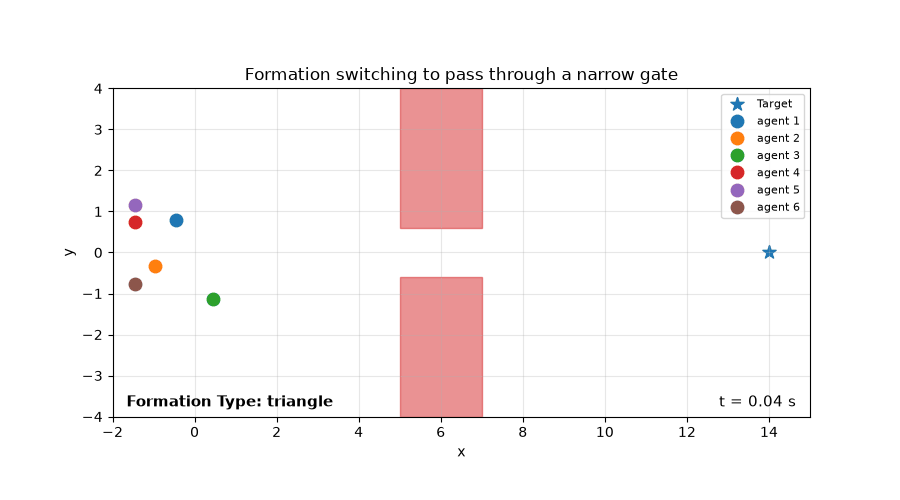

In [22]:
dt = 0.01
n_frame = 1800
steps_per_frame = 4  # Subsampling to speed up animation (4 physics steps per frame)

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter([agent1.target[0]], [agent1.target[1]], color="tab:blue", s=100, marker="*", label="Target")

for obs in narrow_obstacles:
    obs.plot(ax, color="tab:red", alpha=0.5)

pathlines, agentpoints = [], []
for i, agent in enumerate(agents):
    pathline, = ax.plot([], [], "--", lw=1.5, color=colors[i], alpha=0.7)
    agentpoint, = ax.plot([], [], "o", markersize=9, color=colors[i], label=f"agent {i+1}")
    pathlines.append(pathline)
    agentpoints.append(agentpoint)

ax.set_xlim(-2, 15)
ax.set_ylim(-4, 4)
ax.set_aspect("equal")
ax.set_title("Formation switching to pass through a narrow gate")
ax.grid(True, alpha=0.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right", fontsize=8)
state_text = ax.text(0.02, 0.02, "", transform=ax.transAxes, va="bottom",
                      fontsize=11, weight="bold")
time_text = ax.text(0.98, 0.02, "", transform=ax.transAxes, va="bottom", ha="right",
                     fontsize=11)

xss = [[a.position[0]] for a in agents]
yss = [[a.position[1]] for a in agents]

def init():
    for i, agent in enumerate(agents):
        pathlines[i].set_data(xss[i], yss[i])
        agentpoints[i].set_data([agent.position[0]], [agent.position[1]])
    state_text.set_text(f"Formation Type: {formation_manager.current}")
    time_text.set_text("t = 0.00 s")
    return *pathlines, *agentpoints, state_text, time_text

def update(frame):
    for _ in range(steps_per_frame):
        formation_manager.update(dt)
        for i, agent in enumerate(agents):
            agent.step(dt)
            xss[i].append(agent.position[0])
            yss[i].append(agent.position[1])
    for i, agent in enumerate(agents):
        pathlines[i].set_data(xss[i], yss[i])
        agentpoints[i].set_data([agent.position[0]], [agent.position[1]])
    state_text.set_text(f"Formation Type: {formation_manager.current}")
    time_text.set_text(f"t = {min((frame + 1) * steps_per_frame * dt, n_frame * dt):.2f} s")
    return *pathlines, *agentpoints, state_text, time_text

anim = FuncAnimation(fig, update, init_func=init, frames=n_frame // steps_per_frame, interval=30, blit=True)
anim.save("assets/formation_switching.gif", writer=PillowWriter(fps=30))
plt.close(fig)
show_gif_player("assets/formation_switching.gif", fps=30, stride=2)

### 3.7 Discussion: Transient Dynamics & Geometric Ambiguity

During the re-expansion phase from line to triangle, trailing followers (e.g. Agent 4) may experience transient crossing or routing toward an alternate wing:
- **Collinear Saddle Point & Reflection Ambiguity:** In pure distance-based control (\|\mathbf{p}_i - \mathbf{p}_j\| = d_{ij}), collapsing onto a line ($y = 0$) zeroes lateral gradients ($\partial d / \partial y = 0$). Symmetrical triangle branches ($\pm y$) have identical potential energies, creating a 50% statistical reflection probability under physical/numerical noise.
- **Time-Step Sensitivity ($dt$):** With different numerical integration steps $dt$, microscopic truncation errors alter symmetry-breaking, allowing followers to branch either into their nominal or mirror positions.
- **Mitigations in Real Robotics:** Displacement-based consensus ($\mathbf{R}(\theta)\mathbf{z}^*$) or bearing/angle constraints provide signed lateral awareness, avoiding reflection ambiguity.


### 3.8 Investigation: Initial Conditions and Reflection Symmetry
Does the final formation settle with one vertex tilted due to algorithmic bias or initial conditions?
Because distance-based rigidity constraints (\Vert \mathbf{p}_i - \mathbf{p}_j \Vert = d_{ij}) only fix edge lengths, the potential landscape contains symmetric isometric minima (**flipped embeddings**). To verify that orientation depends on the initial basin of attraction, seven benchmark cases are evaluated:
1. **Case A (Asymmetric Launch, $y_0 = +0.8$):** Original test setup.
2. **Case B (Mirrored Inversion, $y_0 = -0.8$):** Exact spatial reflection across the centerline ($y \to -y$).
3. **Case C (Symmetric Bilateral, $y_0 = 0.0$):** Symmetrically placed agents along the motion centerline.
4. **Case D (Shifted Down, $y_0 = -1.0$):** Entire fleet shifted downward by 1.0 unit relative to Case C with the same goal.
5. **Case E (Mirrored Shifted Down, $y_0 = +1.0$):** Exact spatial reflection across the centerline ($y \to -y$) of Case D.
6. **Case F (Shifted Up, $y_0 = +1.0$):** Entire fleet shifted upward by 1.0 unit relative to Case C with the same goal.
7. **Case G (Mirrored Shifted Up, $y_0 = -1.0$):** Exact spatial reflection across the centerline ($y \to -y$) of Case F.


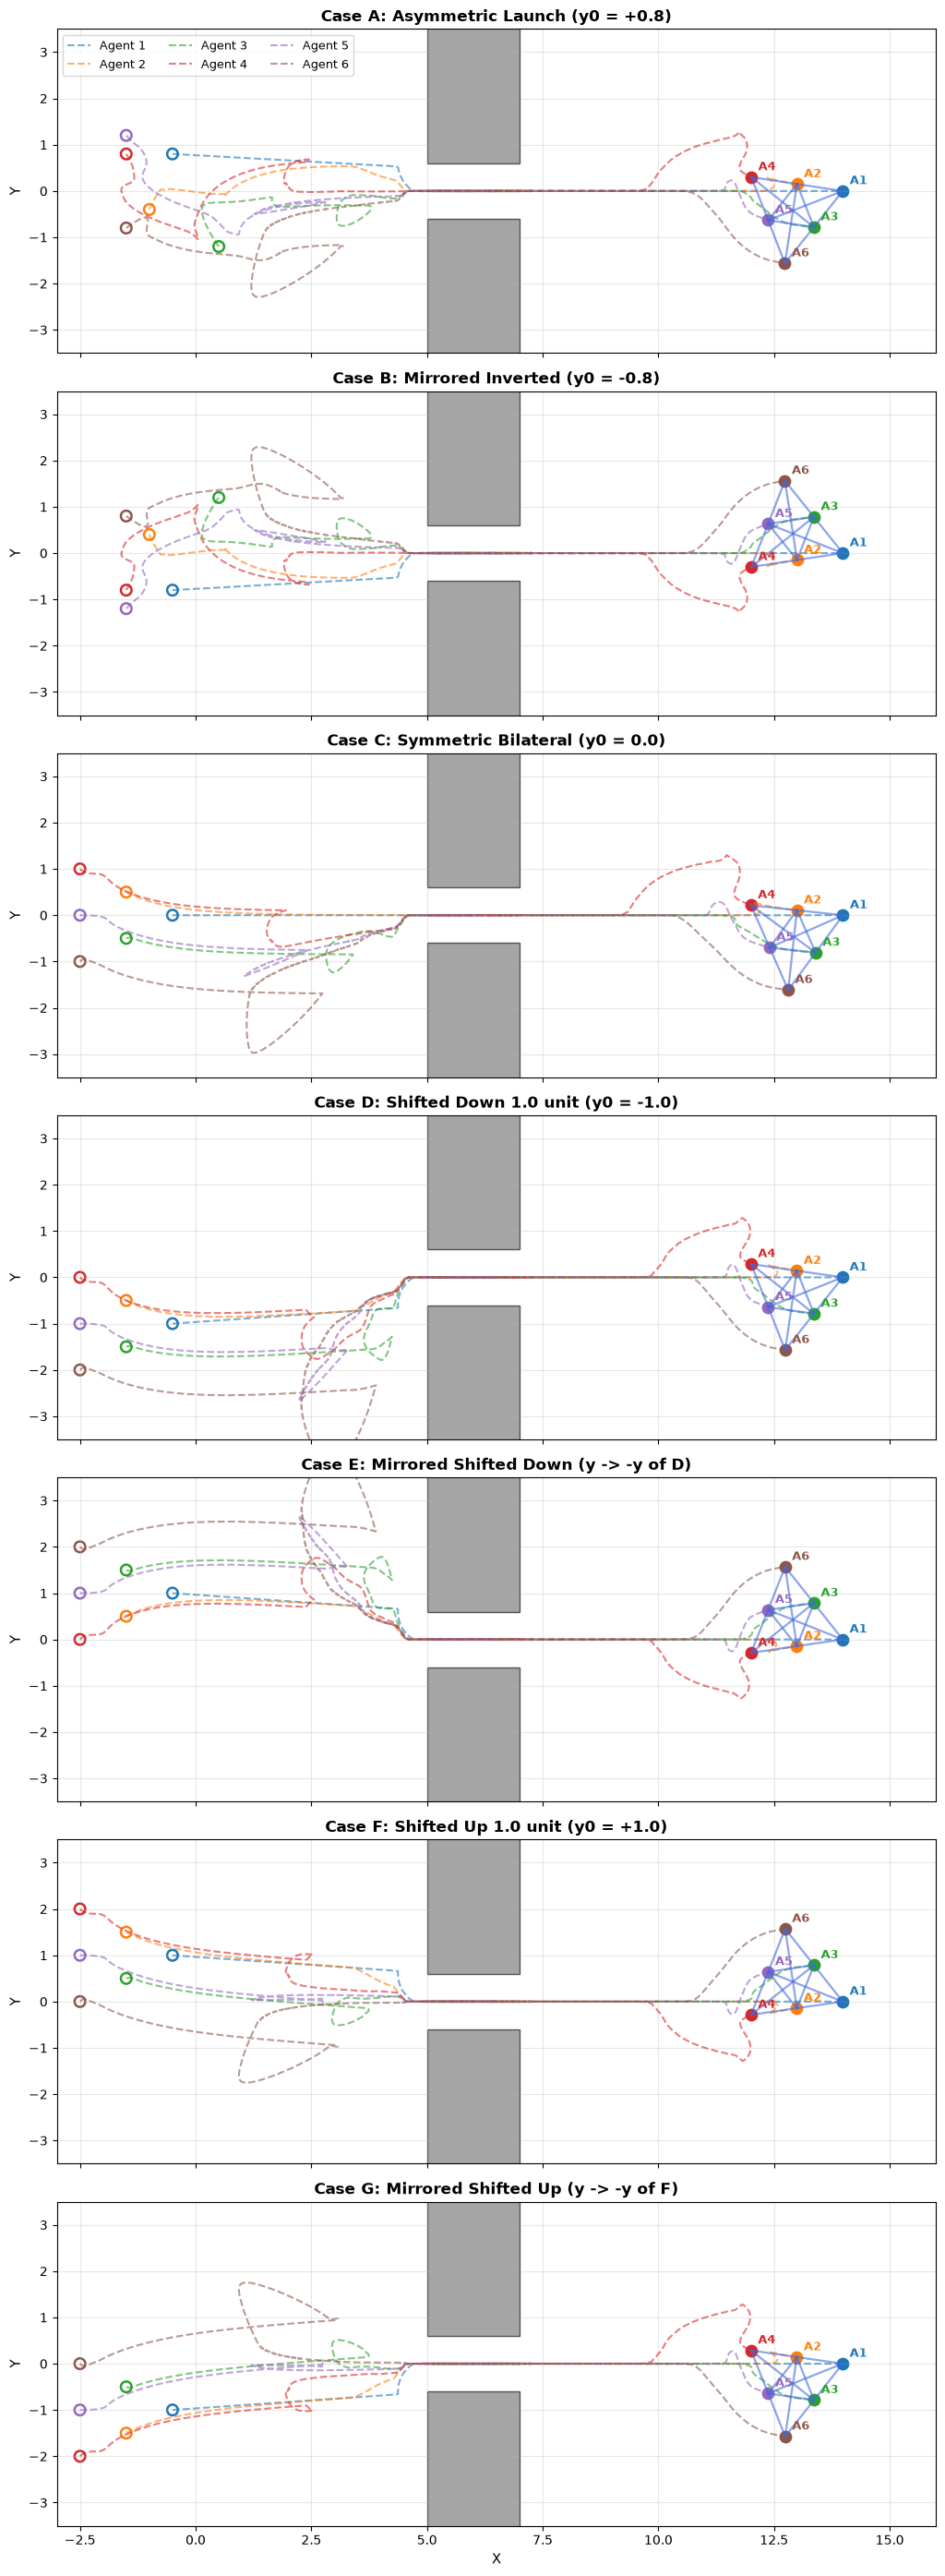

In [25]:
# Comparative Benchmark: Final Converged Formations at t = 18.0 s (n_frame = 1800)
def run_formation_experiment(initial_positions, target=[14.0, 0.0], dt=0.01, n_steps=1800):
    gate_top = Obstacle(
        geometry=Polygon([(5, 0.6), (7, 0.6), (7, 4), (5, 4)]),
        name="gate_top", influence_radius=0.8, safe_distance=0.3,
    )
    gate_bottom = Obstacle(
        geometry=Polygon([(5, -4), (7, -4), (7, -0.6), (5, -0.6)]),
        name="gate_bottom", influence_radius=0.8, safe_distance=0.3,
    )
    obstacles = [gate_top, gate_bottom]

    leader = Agent(position=initial_positions[0], behaviors=[GoalSeeking(k=1.0)], target=target, speed=1.0)
    followers = [Agent(position=pos, speed=1.8) for pos in initial_positions[1:]]
    agents = [leader] + followers

    for a in agents:
        a.behaviors.append(MutualDistanceKeeping([]))
        a.behaviors.insert(0, ObstacleAvoidanceAPF(
            obstacles=lambda a=a: obstacles + [other for other in agents if other is not a],
            gain=1.0
        ))

    mgr = FormationManager(
        agents=agents, obstacles=obstacles,
        reformation_criterion=TraveledDistanceCriterion(),
        unit=1.0, lookahead=1.0, margin=0.3, min_dwell_time=1.0,
        constraint_k=10.0, directed=True
    )

    trajectories = [[] for _ in agents]
    for step in range(n_steps):
        mgr.update(dt)
        for i, a in enumerate(agents):
            trajectories[i].append(a.position.copy())
            a.step(dt)

    return agents, [np.array(tr) for tr in trajectories], obstacles

# Benchmark Initial Configurations
case_c_pos = [
    [-0.5, 0.0], [-1.5, 0.5], [-1.5, -0.5], [-2.5, 1.0], [-2.5, 0.0], [-2.5, -1.0]
]
exp_d_pos = [[p[0], p[1] - 1.0] for p in case_c_pos]  # 1.0 unit lower than Case C
exp_e_pos = [[p[0], -p[1]] for p in exp_d_pos]        # y-symmetric to Case D
exp_f_pos = [[p[0], p[1] + 1.0] for p in case_c_pos]  # 1.0 unit higher than Case C
exp_g_pos = [[p[0], -p[1]] for p in exp_f_pos]        # y-symmetric to Case F

experiments = {
    "Case A: Asymmetric Launch (y0 = +0.8)": [
        [-0.5, 0.8], [-1.0, -0.4], [0.5, -1.2], [-1.5, 0.8], [-1.5, 1.2], [-1.5, -0.8]
    ],
    "Case B: Mirrored Inverted (y0 = -0.8)": [
        [-0.5, -0.8], [-1.0, 0.4], [0.5, 1.2], [-1.5, -0.8], [-1.5, -1.2], [-1.5, 0.8]
    ],
    "Case C: Symmetric Bilateral (y0 = 0.0)": case_c_pos,
    "Case D: Shifted Down 1.0 unit (y0 = -1.0)": exp_d_pos,
    "Case E: Mirrored Shifted Down (y -> -y of D)": exp_e_pos,
    "Case F: Shifted Up 1.0 unit (y0 = +1.0)": exp_f_pos,
    "Case G: Mirrored Shifted Up (y -> -y of F)": exp_g_pos,
}

# Vertically Stacked Comparative Plot (7x1 layout, enlarged dimensions)
fig, axes = plt.subplots(7, 1, figsize=(14, 28), sharex=True, sharey=True)
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

for ax_idx, (title, init_pos) in enumerate(experiments.items()):
    ax = axes[ax_idx]
    agents, trajs, obsts = run_formation_experiment(init_pos, dt=0.01, n_steps=1800)
    
    # Plot Obstacles
    for obs in obsts:
        x_poly, y_poly = obs.geometry.exterior.xy
        ax.fill(x_poly, y_poly, color="dimgray", alpha=0.6, edgecolor="black")
    
    # Plot Trajectories and Agent Positions at Final Frame (t = 18.0 s)
    for i, (traj, color) in enumerate(zip(trajs, colors)):
        ax.plot(traj[:, 0], traj[:, 1], color=color, linestyle="--", alpha=0.6, lw=1.5, label=f"Agent {i+1}" if ax_idx == 0 else "")
        ax.scatter(traj[0, 0], traj[0, 1], color=color, marker="o", facecolors="none", s=70, linewidths=1.8)
        ax.scatter(traj[-1, 0], traj[-1, 1], color=color, marker="o", s=80)
        ax.text(traj[-1, 0]+0.15, traj[-1, 1]+0.15, f"A{i+1}", fontsize=9, color=color, fontweight="bold")
    
    # Plot Rigid Formation Constraint Edges at Final Equilibrium
    final_pos = [a.position for a in agents]
    for p_idx, c_idx, _ in TRIANGLE_SPECS:
        p1, p2 = final_pos[p_idx], final_pos[c_idx]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="royalblue", alpha=0.6, linewidth=1.6)
    
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Y", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 16)
    ax.set_ylim(-3.5, 3.5)

axes[-1].set_xlabel("X", fontsize=11)
axes[0].legend(loc="upper left", fontsize=9, ncol=3)
plt.tight_layout()
# Save static comparative plot to assets/
plt.savefig("assets/formation_symmetry_comparison.png", dpi=150)
plt.show()


### 3.9 Key Observations & Takeaways
- **Strict Reflection Symmetry ($y \to -y$):** Inverting initial coordinates across $y=0$ produces an exact spatial reflection of the entire trajectory field and final formation across the motion centerline. This is consistently demonstrated across all three mirrored pairs:
  - **Case A vs Case B:** Original launch tilted toward $+y$ mirrors to $-y$.
  - **Case D vs Case E:** Downward-shifted launch ($\\Delta y = -1.0$, entering the gate from below with $\\dot{y} > 0$) mirrors the upward-shifted inverted launch ($\\Delta y = +1.0$, entering from above with $\\dot{y} < 0$).
  - **Case F vs Case G:** Upward-shifted launch ($\\Delta y = +1.0$) mirrors the downward-shifted inverted launch ($\\Delta y = -1.0$).
- **Dynamic Basin Selection Governed by Approach Direction:** When the fleet starts below the gate axis ($y_0 = -1.0$, as in **Case D** and **Case G**), its upward transverse momentum and repulsions from the lower obstacle bias the re-expansion into the downward-tilted isometric minimum ($A_6$ pointing toward negative $y$). Conversely, approaching from above ($y_0 = +1.0$, as in **Case E** and **Case F**) channels the fleet into the upward-tilted minimum ($A_6$ pointing toward positive $y$).
- **Topological Robustness Under Agent Role Permutations:** Comparing **Case D** and **Case G** (and likewise **Case E** and **Case F**), both fleets occupy the exact same spatial coordinates initially, but with reversed top-vs-bottom agent assignments. In both cases, the final geometric formation converges to the exact same shape and orientation, proving that structural basin attraction dominates over individual agent identity permutations.
- **Information Bottleneck & Memory Retention:** The 1D line collapse inside the narrow gate does not erase all memory: kinetic inertia and asymmetrical obstacle contact provide the initial condition bias that dictates how the fleet expands post-gate. In the singular case **Case C** ($y_0 = 0.0$), the system reaches a collinear saddle point, where numerical roundoff breaks symmetry.
- **Design Takeaway for Real Swarms:** Pure distance-based rigidity constraints (\Vert \mathbf{p}_i - \mathbf{p}_j \Vert = d_{ij}) are isometric and cannot disambiguate between mirrored configurations. To enforce a deterministic wing allocation (e.g. fixed left/right roles), distance control must be augmented with signed bearing/angle constraints or displacement consensus $\mathbf{R}(\theta)\mathbf{z}^*$.
